# 0 · Data and the forecast experiment

**Recipe → command → artifact → interpretation.** Module 2's recipe has already produced a shared ERA5 store. Here we establish what its arrays mean and what a forecast experiment is allowed to learn from. The following notebooks build a spatial graph, train from YAML, and evaluate native CLI forecasts.

| Notebook | Native Anemoi command | Evidence to inspect |
|---|---|---|
| 0 · Data | `anemoi-datasets inspect DATASET` | Axes, dates, variables, statistics |
| 1 · Graph | `anemoi-graphs create GRAPH.yaml GRAPH.pt` | Directed edges, geometry, area weights |
| 2 · Train | `anemoi-training train --config-name forecast_6h` | Resolved settings, losses, checkpoint |
| 3 · Forecast | `anemoi-inference run INFERENCE.yaml` | Fields, lead times, error against persistence |

**Allow 25–35 minutes.** You should be able to read Python array slices and a YAML mapping. By the end, explain the four dataset axes, distinguish predicted fields from supporting inputs, and check that an example's history and target belong to the intended split. Short discussion notes follow the exercises; make your prediction before opening them.

Run **0 → 1 → 2 → 3**. Notebooks 0 and 1 run on CPU; 2 and 3 need a CUDA GPU. These practicals use the pinned Module 3–4 environment; the lecture has a separate, newer environment.


> **Before you start**
>
> - **Environment:** from the repository root run `uv sync --group module-03-04`, start JupyterLab with `uv run jupyter lab`, and open this notebook with the `python3` kernel.
> - **Data:** `data/module-03_04/` must contain `era5-o48-2020-2021-6h-v0.zarr` and `grids/grid-o32.npz`. Download the course record ([doi:10.5281/zenodo.23099483](https://doi.org/10.5281/zenodo.23099483)) and run `unzip course-module-03_04.zip` from the repository root.
> - **Outputs:** everything the notebooks create is written to `output/module-03_04/`.
> - **Hardware:** no GPU needed.
> - **Order:** start here; nothing from earlier notebooks is required.

## 1. Locate the prepared data and environment

Run these notebooks with the `module-03-04` environment (`uv sync --group module-03-04`) as the `python3` kernel. The setup cell moves to the repository root, defines the data, output and config paths used below and checks the environment; the Anemoi operations remain visible in shell cells, each with its config path written out.

`%%bash` runs Bash. `set -euo pipefail` makes a failing command fail the cell, including when its output is piped through `tee`. Keep the store under `data/module-03_04/` read only; reports and later artifacts go to `output/module-03_04/`.


In [1]:
import os
import sys
from pathlib import Path

# Work from the repository root (the folder with pyproject.toml), whatever directory JupyterLab was started from
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
os.chdir(root)

# Inputs, outputs and configs of Modules 3-4 (the two environment variables can override the defaults)
DATA = Path(os.environ.get("ANEMOI_COURSE_DATA", "data/module-03_04")).resolve()
OUTPUT = Path(os.environ.get("ANEMOI_COURSE_OUTPUT", "output/module-03_04")).resolve()
DATASET = DATA / "era5-o48-2020-2021-6h-v0.zarr"
CONFIG_DIR = Path("configs/module-03_04")

# The Hydra configs and the %%bash cells read the two paths from environment variables
os.environ["ANEMOI_COURSE_DATA"] = str(DATA)
os.environ["ANEMOI_COURSE_OUTPUT"] = str(OUTPUT)
# Run the anemoi-* commands of this environment
os.environ["PATH"] = f"{Path(sys.executable).parent}{os.pathsep}{os.environ['PATH']}"

sys.path.insert(0, "notebooks/module-03_04")
from course import check_environment

check_environment(DATASET, DATA / "grids/grid-o32.npz", OUTPUT, gpu=False)

{
  "data": "/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets",
  "output": "/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312",
  "versions": {
    "anemoi-datasets": "0.5.36",
    "anemoi-graphs": "0.9.3",
    "anemoi-inference": "0.10.1",
    "anemoi-models": "0.14.1",
    "anemoi-training": "0.12.1",
    "anemoi-transform": "0.3.1",
    "anemoi-utils": "0.5.3"
  }
}


{'data': '/gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets',
 'output': '/gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312',
 'versions': {'anemoi-datasets': '0.5.36',
  'anemoi-graphs': '0.9.3',
  'anemoi-inference': '0.10.1',
  'anemoi-models': '0.14.1',
  'anemoi-training': '0.12.1',
  'anemoi-transform': '0.3.1',
  'anemoi-utils': '0.5.3'}}

In [2]:
import shutil
for command in ("anemoi-datasets", "anemoi-graphs", "anemoi-training", "anemoi-inference"):
    print(command, "→", shutil.which(command))
print("Dataset:", DATASET)
print("Personal output:", OUTPUT)
print("Config directory:", CONFIG_DIR)


anemoi-datasets → /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/bin/anemoi-datasets
anemoi-graphs → /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/bin/anemoi-graphs
anemoi-training → /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/bin/anemoi-training
anemoi-inference → /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/.venv-course/bin/anemoi-inference
Dataset: /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-gpu-audit/assets/era5-o48-2020-2021-6h-v0.zarr
Personal output: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312
Recipe directory: /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/workspace/notebooks/module-03-04/configs


## 2. Read the store's contract before reading its values

**Predict:** on an octahedral reduced Gaussian grid, will the last axis be a rectangular longitude dimension? Which axis will remain present even though this store has only one ensemble member?

The native command inspects metadata and stored statistics. It does not create or download the dataset. Identify the date interval, temporal spacing, variable count, and spatial point count.


In [3]:
%%bash
set -euo pipefail
anemoi-datasets inspect "$ANEMOI_COURSE_DATA/era5-o48-2020-2021-6h-v0.zarr" \
  | tee "$ANEMOI_COURSE_OUTPUT/dataset-inspect.txt"


2026-09-25 01:33:54 INFO Using environment variable ANEMOI_CONFIG_PATH to override the anemoi config

 key 'path.'


📦 Path          : /gpfs/home/bsc/bsc437208/gitlab/climate-data-ai-anemoi/artifacts/module-03-04-g

pu-audit/assets/era5-o48-2020-2021-6h-v0.zarr
🔢 Format version: 0.30.0

📅 Start      : 2020-01

-01 00:00
📅 End        : 2021-12-31 18:00
⏰ Frequency  : 6h
🚫 Missing    : 0
🌎 Resolution

...

822.68
      40 │ z_850          │      6671.23 │   16961.5 │      14286.1 │     1239.99
 

  ──────┴────────────────┴────────

──────┴───────────┴──────────────┴

────────────
🔋 Dataset ready, last update last year.
📊 Statistics read

y.





Named axes connect the store to a two-state input history and a separate future target. This diagram is schematic; the next cell reads the actual store.


In [4]:
import numpy as np
import pandas as pd
from anemoi.datasets import open_dataset

dataset = open_dataset(str(DATASET))
axis_names = ["time", "variable", "member", "point"]
display(pd.DataFrame({"axis": axis_names, "length": dataset.shape}))
assert len(dataset.shape) == 4
assert dataset.shape[1] == len(dataset.variables)
assert dataset.shape[2] == 1  # a retained singleton axis, not an ensemble experiment
assert dataset.shape[-1] == len(dataset.latitudes) == len(dataset.longitudes)
dates = np.asarray(dataset.dates)
assert np.all(np.diff(dates) == np.timedelta64(6, "h"))
print("First / last state:", dates[0], dates[-1])
print("First variable names:", dataset.variables[:10])
print("Point coordinates align with the last axis; do not reshape it to lat × lon.")


,axis,length
0,time,2924
1,variable,41
2,member,1
3,point,10944


First / last state: 2020-01-01T00:00:00 2021-12-31T18:00:00
First variable names: ['10u', '10v', '2d', '2t', 'cos_julian_day', 'cos_latitude', 'cos_local_time', 'cos_longitude', 'insolation', 'lsm']
Point coordinates align with the last axis; do not reshape it to lat × lon.


<details><summary>Discussion: why four axes do not imply an ensemble forecast</summary>

The member axis is part of the storage interface; its length is one here. Ensemble forecasting requires an experiment that generates or models multiple possible outcomes. O48 uses a varying number of longitudes per latitude ring, so the 10,944 point coordinates must travel with their values. An arbitrary rectangular reshape would scramble their meaning.
</details>


## 3. Read variable roles from the training recipe

The store is larger than the experiment. `dataloader.dataset.select` chooses a named subset; never infer a variable's identity from an index remembered from another dataset. Our six predicted fields are three geopotentials, two temperatures, and total column water. Other selected fields describe geography, time, or solar forcing. Geography is fixed; calendar and solar inputs can be computed for future valid times without observing future weather.

**Predict:** why can future local time be an input during a rollout while future 2 m temperature cannot? The YAML below selects the fields; its inherited data defaults supply their forcing roles, which Notebook 2 resolves.


In [5]:
%%bash
set -euo pipefail
cat configs/module-03_04/forecast_6h.yaml


# Course-specific choices. Library defaults are loaded from the installed Anemoi
# package, whose so

urce and licence remain with that dependency.
defaults:
  - data: zarr
  - dataloader: native_grid
 

 - diagnostics: evaluation
  - system: example
  - model: transformer
  - task: forecaster
  - train

ing: single
  - graph: o48_o32
  - override training/scalers: course_uniform
  - _self_

config_vali

dation: True

system:
  input:
    dataset: ${oc.env:ANEMOI_COURSE_DATA}/era5-o48-2020-2021-6h-v0.za

...

  ignore_nans: False
  metrics:
    datasets:
      data: [z_500, t_850, 2t]

diagnostics:
  callbac

ks: []
  plot:
    callbacks: []
  enable_progress_bar: False
  checkpoint:
    every_n_minutes:
   

   save_frequency: null
    every_n_epochs:
      num_models_saved: 3
  log:
    interval: 1
    mlf

low:
      enabled: True
      offline: True
      tracking_uri: null
      experiment_name: ${oc.en

v:USER}-forecast-6h
      system: True


In [6]:
import yaml
recipe = yaml.safe_load((CONFIG_DIR / "forecast_6h.yaml").read_text())
selected = recipe["dataloader"]["dataset"]["select"]
forecast_units = {"z_1000": "m² s⁻²", "z_500": "m² s⁻²", "2t": "K",
                  "t_850": "K", "tcw": "kg m⁻²", "z_250": "m² s⁻²"}
forecast_names = list(forecast_units)
assert set(selected).issubset(dataset.variables)
assert set(forecast_names).issubset(selected)
roles = pd.DataFrame({
    "variable": selected,
    "store index": [dataset.variables.index(name) for name in selected],
    "role in this recipe": ["predicted weather" if name in forecast_units else "supporting input" for name in selected],
    "forecast units": [forecast_units.get(name, "— (inspect metadata)") for name in selected],
})
display(roles)
print("Selected", len(selected), "fields; forecast fields:", forecast_names)
print("The suffixes 1000 / 850 / 500 / 250 refer to pressure levels in hPa.")


,variable,store index,role in this recipe,forecast units
0,z_1000,37,predicted weather,m² s⁻²
1,z_500,39,predicted weather,m² s⁻²
2,2t,3,predicted weather,K
3,t_850,26,predicted weather,K
4,tcw,27,predicted weather,kg m⁻²
5,z_250,38,predicted weather,m² s⁻²
6,lsm,9,supporting input,— (inspect metadata)
7,z,36,supporting input,— (inspect metadata)
8,cos_latitude,5,supporting input,— (inspect metadata)
9,cos_longitude,7,supporting input,— (inspect metadata)


Selected 19 fields; forecast fields: ['z_1000', 'z_500', '2t', 't_850', 'tcw', 'z_250']
The suffixes 1000 / 850 / 500 / 250 refer to pressure levels in hPa.


Geopotential is **not** height in metres: dividing by a reference gravitational acceleration would convert it to geopotential height. Keep the stored units in plots and error labels. A temperature difference has the same numerical value in K and °C, but an absolute temperature does not.

<details><summary>Discussion: known inputs versus future observations</summary>

Valid time and location determine calendar and solar features, so they can be generated at inference. ERA5 weather at the target time is available only for supervision and verification. The model's input/forcing/output indices, resolved in Notebook 2 and stored with its checkpoint, determine how the selected fields are used.
</details>


## 4. Separate input history from the target

Take three consecutive states from the test period. The forecast reference time is **1 July 2021, 06:00 UTC**: 00:00 and 06:00 are history; 12:00 is the +6 h target. A two-state history is not a two-step forecast. Select by name and date before materializing this small window.


In [7]:
window = open_dataset(str(DATASET), select=["2t"],
                      start="2021-07-01T00:00:00", end="2021-07-01T12:00:00")
raw_window = np.asarray(window[:])
assert raw_window.shape == (3, 1, 1, dataset.shape[-1])
values = raw_window[:, 0, 0, :]  # explicitly remove the variable and member axes
history = values[:2].copy()
target = values[2].copy()
reference_time = window.dates[1]
assert recipe["task"]["multistep_input"] == history.shape[0]
assert np.all(np.diff(window.dates) == np.timedelta64(6, "h"))
assert target.shape == history.shape[1:]
display(pd.DataFrame({"valid time (UTC)": window.dates,
                      "use": ["older input: t − 6 h", "latest input: t", "target: t + 6 h"]}))
print("Input shape:", history.shape, "| separate target shape:", target.shape)
assert np.isfinite(values).all()


,valid time (UTC),use
0,2021-07-01 00:00:00,older input: t − 6 h
1,2021-07-01 06:00:00,latest input: t
2,2021-07-01 12:00:00,target: t + 6 h


Input shape: (2, 10944) | separate target shape: (10944,)


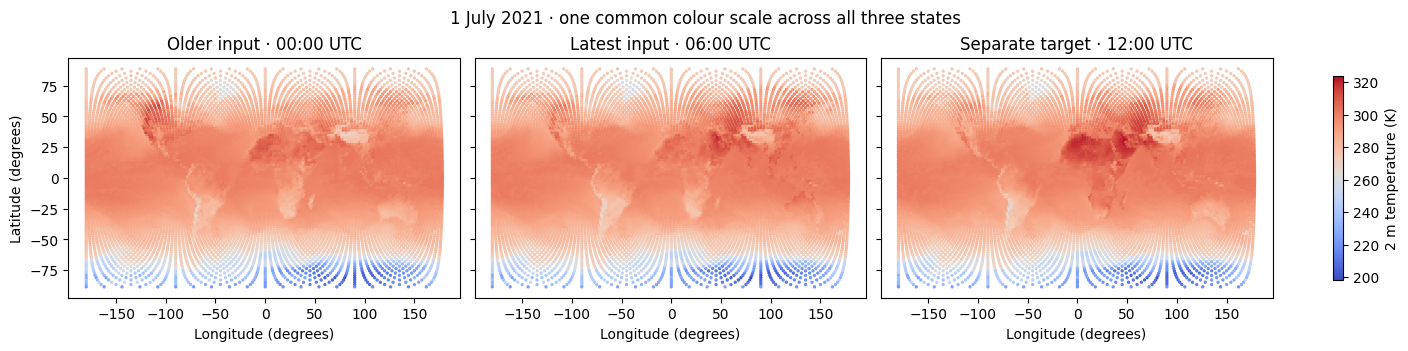

In [8]:
import matplotlib.pyplot as plt
longitudes = (np.asarray(window.longitudes) + 180) % 360 - 180
latitudes = np.asarray(window.latitudes)
colour_min, colour_max = float(values.min()), float(values.max())
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharex=True, sharey=True, layout="constrained")
for ax, field, date, role in zip(axes, values, window.dates, ["Older input", "Latest input", "Separate target"]):
    points = ax.scatter(longitudes, latitudes, c=field, s=2, cmap="coolwarm",
                        vmin=colour_min, vmax=colour_max, rasterized=True)
    ax.set(title=f"{role} · {str(date)[11:16]} UTC", xlabel="Longitude (degrees)")
axes[0].set_ylabel("Latitude (degrees)")
fig.colorbar(points, ax=axes, label="2 m temperature (K)", shrink=0.85)
fig.suptitle("1 July 2021 · one common colour scale across all three states")
plt.show()


**Read the maps:** broad temperature contrasts change slowly. A nearly unchanged map is not evidence that a model has learned the six-hour evolution. Plot the target minus the latest input on its own scale; this is also the signed error of a persistence forecast with its sign reversed.


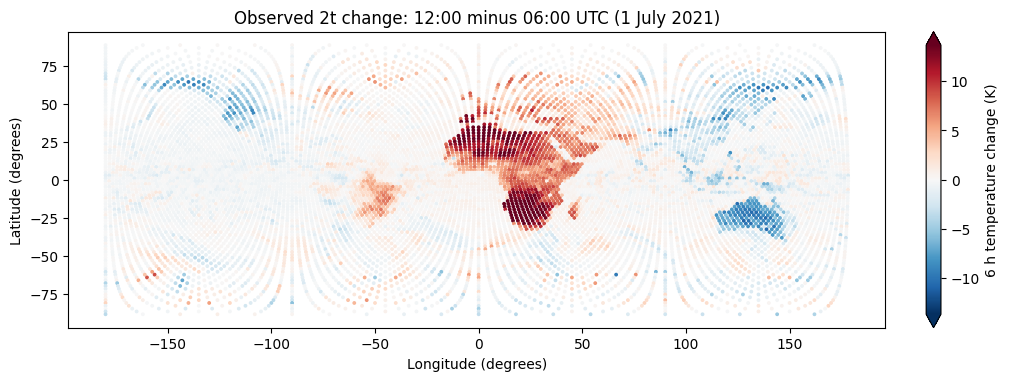

Display limits use the 99th percentile of |change|; extremes may saturate.
Unweighted grid-point RMS change: 3.171 K
This is one case; spatially weighted forecast verification comes in Notebook 3.


In [9]:
change = target - history[-1]
limit = max(float(np.quantile(np.abs(change), 0.99)), 1e-6)
fig, ax = plt.subplots(figsize=(10, 3.7), layout="constrained")
points = ax.scatter(longitudes, latitudes, c=change, s=3, cmap="RdBu_r",
                    vmin=-limit, vmax=limit, rasterized=True)
ax.set(xlabel="Longitude (degrees)", ylabel="Latitude (degrees)",
       title="Observed 2t change: 12:00 minus 06:00 UTC (1 July 2021)")
fig.colorbar(points, ax=ax, label="6 h temperature change (K)", extend="both")
plt.show()
print("Display limits use the 99th percentile of |change|; extremes may saturate.")
print("Unweighted grid-point RMS change:", round(float(np.sqrt(np.mean(change**2))), 3), "K")
print("This is one case; spatially weighted forecast verification comes in Notebook 3.")


## 5. Inspect units and stored normalization statistics

Training combines fields with very different numerical scales. Inspect the store's mean and standard deviation before interpreting normalized loss. A standard score `(x − mean) / stdev` is dimensionless; it is not an anomaly against a day-of-year climatology. The training recipe can use different normalization modes for supporting fields.

**Predict:** must the spatial average of one normalized temperature snapshot be zero? Would a zero standard deviation be safe for this formula?


In [10]:
statistics = dataset.statistics
stat_rows = []
for name, unit in forecast_units.items():
    index = dataset.variables.index(name)
    stat_rows.append({"variable": name, "unit": unit,
                      "stored mean": float(statistics["mean"][index]),
                      "stored stdev": float(statistics["stdev"][index])})
stats_table = pd.DataFrame(stat_rows).set_index("variable")
display(stats_table)
assert np.isfinite(stats_table[["stored mean", "stored stdev"]].to_numpy()).all()
assert (stats_table["stored stdev"] > 0).all()
two_t_index = dataset.variables.index("2t")
mean_2t, std_2t = statistics["mean"][two_t_index], statistics["stdev"][two_t_index]
normalized_latest = (history[-1] - mean_2t) / std_2t
print("Latest input: mean", round(float(history[-1].mean()), 3), "K")
print("Normalized spatial mean", round(float(normalized_latest.mean()), 3),
      "and stdev", round(float(normalized_latest.std()), 3))


,unit,stored mean,stored stdev
variable,,,
z_1000,m² s⁻²,943.064920,915.955696
z_500,m² s⁻²,55645.477044,2822.678352
2t,K,287.829879,16.139447
t_850,K,281.670865,12.654544
tcw,kg m⁻²,25.501518,17.517983
z_250,m² s⁻²,103869.399563,4752.648151


Latest input: mean 289.266 K
Normalized spatial mean 0.089 and stdev 0.958


In [11]:
import json
# This prepared Zarr v2 store records creation/statistics metadata in root attributes.
store_metadata = json.loads((Path(DATASET) / ".zattrs").read_text())
period_keys = [key for key in store_metadata
               if "statistics" in key and any(word in key for word in ("date", "start", "end", "period"))]
print("Recorded statistics period:", {key: store_metadata[key] for key in period_keys}
      or "No explicit statistics-period field; inspect the data recipe/provenance.")
print("Available statistics arrays:", sorted(statistics))
print("Selecting dates with open_dataset does not fit new training-only statistics.")


Recorded statistics period: {'statistics_end_date': '2021-08-07T12:00:00', 'statistics_start_date': '2020-01-01T00:00:00'}
Available statistics arrays: ['maximum', 'mean', 'minimum', 'stdev']
Selecting dates with open_dataset does not fit new training-only statistics.


<details><summary>Discussion: normalization and the limits of this prepared store</summary>

A snapshot need not match a mean calculated over a longer period, and its spatial spread need not be one after normalization. Positive standard deviations are necessary for this calculation; constant features need another normalization policy. This practical reuses the prepared store's statistics rather than rebuilding strictly training-only statistics. The recorded statistics period extends into validation and early test (through 7 August 2021). Disjoint raw dates therefore do not isolate this preprocessing step from held-out data. Treat this as a workflow exercise, not a clean benchmark. A research experiment should document and fit every learned preprocessing statistic on its training period.
</details>


## 6. Check chronological splits and complete windows

The YAML uses 2020 for training, January–June 2021 for validation, and July–December 2021 for test. Validation guides model choices; reserve test for the final comparison. Randomly shuffling overlapping windows across those sets would expose almost identical weather states on both sides.

A valid example needs **both history states and the target** inside its split. Date ranges are inclusive in the Anemoi reader. A split ending on 31 December includes its available states that day; it does not authorize the next day's target.




Training, validation, and test have different purposes. This schematic is followed by actual split dates read from YAML.


In [12]:
split_views, split_rows = {}, []
for split in ("training", "validation", "test"):
    settings = recipe["dataloader"][split]["datasets"]["data"]
    view = open_dataset(str(DATASET), select=["2t"],
                        start=str(settings["start"]), end=str(settings["end"]))
    split_views[split] = view
    split_rows.append({"split": split, "first state": view.dates[0], "last state": view.dates[-1],
                       "states": len(view.dates), "complete 2-input / 1-target windows": len(view.dates) - 2})
display(pd.DataFrame(split_rows).set_index("split"))
assert split_views["training"].dates[-1] < split_views["validation"].dates[0]
assert split_views["validation"].dates[-1] < split_views["test"].dates[0]
assert window.dates[0] >= split_views["test"].dates[0]
assert window.dates[-1] <= split_views["test"].dates[-1]
print("Window counts assume contiguous six-hour states, one-step targets, and stride one.")


,first state,last state,states,complete 2-input / 1-target windows
split,,,,
training,2020-01-01,2020-12-31 18:00:00,1464,1462
validation,2021-01-01,2021-06-30 18:00:00,724,722
test,2021-07-01,2021-12-31 18:00:00,736,734


Window counts assume contiguous six-hour states, one-step targets, and stride one.


## 7. Make one controlled data selection

Change only the **time window**: keep the same variable, grid, and nearest point, but inspect five days instead of three states. We choose the grid point nearest Barcelona using great-circle angular separation, not raw longitude differences. No geographic package or network map is needed.

**Predict:** how many six-hour states should a five-day inclusive date range contain? Will a local trace reproduce the global spatial average?


Selected point: 1701 lat/lon: 41.96822026907537 3.0
Distance to requested location: 94 km


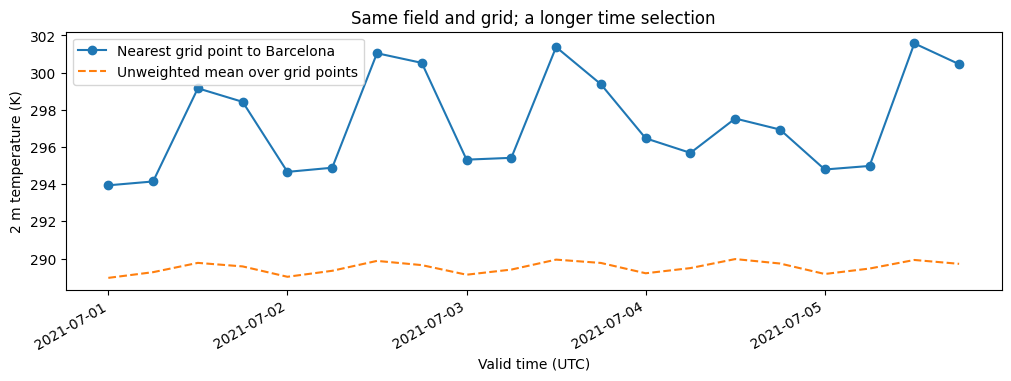

In [13]:
site_lat, site_lon = 41.39, 2.17
lat_radians = np.deg2rad(latitudes)
delta_lon = np.deg2rad(longitudes - site_lon)
cos_separation = (np.sin(lat_radians) * np.sin(np.deg2rad(site_lat))
                  + np.cos(lat_radians) * np.cos(np.deg2rad(site_lat)) * np.cos(delta_lon))
site_index = int(np.argmax(cos_separation))
series_view = open_dataset(str(DATASET), select=["2t"],
                           start="2021-07-01", end="2021-07-05")
series = np.asarray(series_view[:])[:, 0, 0, :]  # only 20 states, one variable
assert len(series_view.dates) == 20
print("Selected point:", site_index, "lat/lon:", latitudes[site_index], longitudes[site_index])
distance_km = 6371 * np.arccos(np.clip(cos_separation[site_index], -1, 1))
print("Distance to requested location:", round(float(distance_km)), "km")
fig, ax = plt.subplots(figsize=(10, 3.7), layout="constrained")
ax.plot(series_view.dates, series[:, site_index], "o-", label="Nearest grid point to Barcelona")
ax.plot(series_view.dates, series.mean(axis=1), "--", label="Unweighted mean over grid points")
ax.set(xlabel="Valid time (UTC)", ylabel="2 m temperature (K)", title="Same field and grid; a longer time selection")
ax.legend()
fig.autofmt_xdate()
plt.show()


**Exercise (3 minutes):** change `site_lat, site_lon` to another location and rerun this cell. Explain one difference in the trace without treating this coarse grid point as a station observation. Then explain why the unweighted line is not an exact global area mean.

<details><summary>Discussion notes</summary>

Five complete days contain 20 states at 00, 06, 12, and 18 UTC. A point and a global average sample different phenomena; averaging suppresses local changes. Coastline, elevation, land/sea mixture, and the coarse grid all limit interpretation of the nearest point. The reduced Gaussian grid does not give every point exactly the same area; Notebook 1 inspects weights for a spatial integral. Neither a five-day trace nor one temperature map establishes general forecast skill.
</details>


## 8. Record the handoff and explain one failure

Save a small data contract for your experiment notes. It records what we inspected, not a new dataset. The next notebook reads the same coordinates to build `graphs/o48-o32.pt`.

**Result-reading exercise:** a colleague removes the singleton member axis and then uses `array[:, variable_index, 0, :]`. What will fail? Another colleague puts the 12:00 temperature in the history to predict 12:00. Which check can catch the first mistake, and why is the second scientifically worse even if the shapes are valid?


In [14]:
data_contract = {
    "dataset": str(DATASET), "shape": list(dataset.shape), "axes": axis_names,
    "selected_variables": selected, "forecast_units": forecast_units,
    "history_dates": [str(date) for date in window.dates[:2]],
    "target_date": str(window.dates[2]), "forecast_step_hours": 6,
    "statistics_policy": "reuse prepared-store statistics; not refitted on the training split",
}
contract_path = OUTPUT / "data-contract.json"
contract_path.write_text(json.dumps(data_contract, indent=2) + "\n")
print("Wrote", contract_path)
print("Next: inspect a graph recipe that reads this exact grid.")


Wrote /gpfs/scratch/bsc32/bsc437208/module03_04-intermediate-20260925/20260924T233312/data-contract.json
Next: inspect a graph recipe that reads this exact grid.


<details><summary>Discussion notes and exit check</summary>

Removing an axis changes the indexing contract and causes too many indices or selects the wrong dimension; explicit slices and shape checks catch that. A future target can have a perfectly valid shape while leaking the answer into the input. Checks on dates and variable roles, backed by an experiment design, catch that error. Explain the difference between a member axis, a history axis, and a forecast lead time before continuing.
</details>

**Sources and connection to the lecture.** The local [Part 2 lecture](extra/lecture-part-2-data-to-model.ipynb) introduces dataset axes, forcing roles, and splits. The executable contract here is the pinned Anemoi dataset reader plus [the training YAML](../../configs/module-03_04/forecast_6h.yaml). All diagrams are original course schematics; maps and traces are generated from the prepared ERA5 store.
